# CIFAR-10 Project (Part 3) - High-Confidence Error Analysis

This notebook demonstrates the analysis of the mistakes of the improved model  

After building:  
- `01_cifar10_baseline`
- `02_cifar10_improvements`

The focus is on understanding **why the model makes errors**

This helps to understand model weaknesses and dataset challenges

## Load Trained Inference Model

I load the final improved model created in `02_cifar10_improvements`

This version does not include the data augmentation layer, because augmentation is only used during training

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import confusion_matrix
from tensorflow.keras.datasets import cifar10
from tensorflow import keras
from pathlib import Path

model_path = Path("../results/improved_model_inference.keras")

model = keras.models.load_model(model_path)

print("Loaded model:", model_path)
model.summary()

Loaded model: ..\results\improved_model_inference.keras


C:\Users\lb_20\Desktop\Projects\cnn_generalization_project\venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 50 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "improved_inference"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 474,240 (1.81 MB)

 Trainable params: 157,866 (616.66 KB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 315,734 (1.20 MB)

## Check Model Input and Output Shapes

I verify:  
- Input shape (image size)
- Output shape (number of classes)

CIFAR-10 images have shape (32, 32, 3)    
The model outputs probabilities for 10 classes

In [5]:
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

Input shape: (None, 32, 32, 3)
Output shape: (None, 10)


## Load and Prepare Test Data

The CIFAR-10 was loaded again and prepareed the test set:  
- Convert pixel values to float32
- Normalize values to range [0, 1]
- Flatten label shape if needed

This ensures the test data matches the model input format  

In [7]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_test = X_test.astype("float32") / 255.0
y_test = y_test.squeeze()

print(X_test.shape, X_test.dtype, X_test.min(), X_test.max())
print(y_test.shape)

C:\Users\lb_20\Desktop\Projects\cnn_generalization_project\venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


(10000, 32, 32, 3) float32 0.0 1.0
(10000,)


## Generate Predictions and Find Errors

The next step is to:  
- Predict class probabilities
- Convert probabilities to class labels
- Compare predictions with true labels
- Find indices where prediction is wrong

This gives all misclassified images

In [9]:
probs = model.predict(X_test, batch_size = 256, verbose = 0)
pred = probs.argmax(axis = 1)

true = y_test

errors = np.where(pred != true)[0]

print("Errors:", len(errors))

Errors: 1846


## Visualize Misclassified Images

There are several wrong predictions

For each image you can see:  
- True class
- Predicted class
- Prediction confidence

This helps visually inspect model mistakes

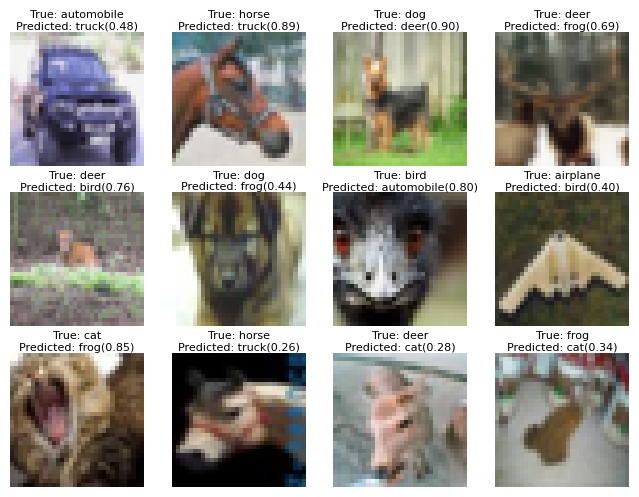

In [11]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

plt.figure(figsize = (8, 8))

for i, idx in enumerate(errors[:12]):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_test[idx])
    conf = probs[idx, pred[idx]]
    plt.title(f"True: {class_names[true[idx]]}\nPredicted: {class_names[pred[idx]]}({conf:.2f})", 
              fontsize = 8, 
              pad = 2)
    plt.axis("off")

plt.show()

## Per-Class Accuracy Analysis

Using the confusion matrix, i calculate:  
Accuracy for each class separately

This shows which categories are easier and which are harder for the model

In [13]:
cm = confusion_matrix(true, pred)
per_class_acc = cm.diagonal() / cm.sum(axis = 1)

for i, acc in enumerate(per_class_acc):
    print(class_names[i], round(acc, 3))

airplane 0.836
automobile 0.901
bird 0.71
cat 0.601
deer 0.778
dog 0.683
frog 0.944
horse 0.852
ship 0.905
truck 0.944


## High-Confidence Wrong Predictions

Here the focus is on errors where the model was very confident

Steps:  
- Get confidence for wrong predictions
- Sort by confidence
- Select top high-confidence mistakes

These errors are important because the model was sure, but still wrong

In [15]:
errors_conf = probs[errors, pred[errors]]
N = 12

top_errors = errors[np.argsort(-errors_conf)[:N]]
top_errors[:5], errors_conf[np.argsort(-errors_conf)[:5]]

(array([2226, 2405, 3645, 3560, 5511]),
 array([0.9998927 , 0.9998878 , 0.9998429 , 0.99944323, 0.9990478 ],
       dtype=float32))

## Visualize Most Confident Errors

The most confident incorrect predictions was displayed

These examples help identify:  
- Confusing classes
- Similar visual patterns

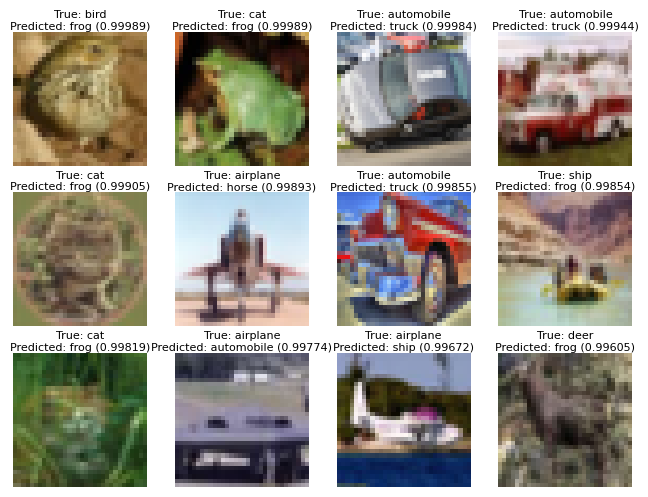

In [17]:
plt.figure(figsize = (8, 8))
for i, idx in enumerate(top_errors):
    plt.subplot(4, 4, i+1)
    plt.imshow(X_test[idx])
    t = class_names[int(true[idx])]
    p = class_names[int(pred[idx])]
    conf = probs[idx, pred[idx]]
    plt.title(f"True: {t}\nPredicted: {p} ({conf:.5f})",
             fontsize = 8, 
             pad = 2)
    plt.axis("off")

RESULTS = Path("../results")
RESULTS.mkdir(exist_ok = True)

out_path = RESULTS / "improved_high_confidence_errors.png"
plt.savefig(out_path, dpi = 300, bbox_inches = "tight")

plt.show()

## Save Error Analysis Results

The final step is to create a structured table with:  
- Image index
- True label
- Predicted label
- Prediction confidence

The results are saved as a CSV file for further analysis

In [19]:
rows = []
for idx in top_errors:
    rows.append({
        "index": int(idx),
        "true_label": int(true[idx]),
        "true_name": class_names[int(true[idx])],
        "pred_label": int(pred[idx]),
        "pred_name": class_names[int(pred[idx])],
        "pred_confidence": float(probs[idx, pred[idx]])})

df_top = pd.DataFrame(rows).sort_values("pred_confidence", ascending = False)
df_top.to_csv(RESULTS / "improved_high_confidence_errors.csv", index = False)

df_top.head(10)

,index,true_label,true_name,pred_label,pred_name,pred_confidence
0,2226,2,bird,6,frog,0.999893
1,2405,3,cat,6,frog,0.999888
2,3645,1,automobile,9,truck,0.999843
3,3560,1,automobile,9,truck,0.999443
4,5511,3,cat,6,frog,0.999048
5,4880,0,airplane,7,horse,0.998931
6,7892,1,automobile,9,truck,0.998550
7,8757,8,ship,6,frog,0.998545
8,3977,3,cat,6,frog,0.998186
9,2532,0,airplane,1,automobile,0.997741
